Running DISCRETE Saaty-scale simulations...

n=4 -> reversal frequency = 0.2918
n=5 -> reversal frequency = 0.4954
n=6 -> reversal frequency = 0.6384
n=7 -> reversal frequency = 0.8008
n=8 -> reversal frequency = 0.8946
n=9 -> reversal frequency = 0.9504

Results saved to: discrete\discrete_iop_results.xlsx


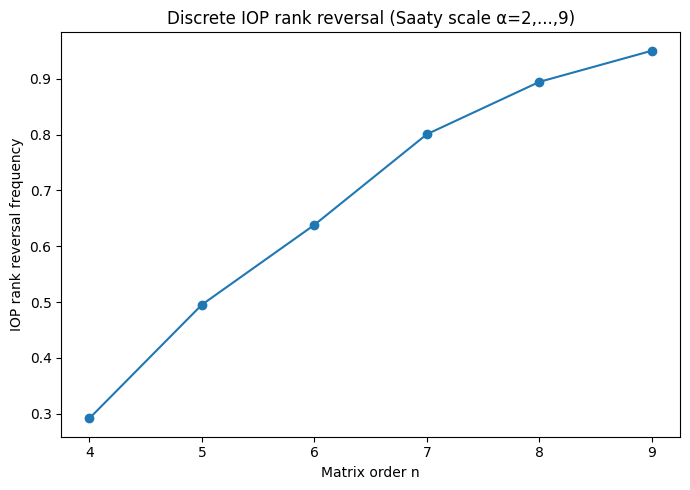

Figure saved to: discrete\discrete_iop_rank_reversal.jpeg


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = eigenvectors[:, idx].real
    w = np.abs(w)
    return w / np.sum(w)


# =========================================================
# 2. Ranking induced by weights
# =========================================================

def ranking(weights):
    return np.argsort(-weights)


# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):
    """
    Generate random ordinal reciprocal matrix with entries:
    {1, P, 1/P}
    """

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:  # notpref
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A


# =========================================================
# 4. Substitute alpha into ordinal PCM
# =========================================================

def substitute_alpha(A_ordinal, alpha):

    n = A_ordinal.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ordinal[i, j] == "P":
                A[i, j] = alpha
            elif A_ordinal[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A


# =========================================================
# 5. Discrete IOP rank reversal experiment
# =========================================================

def discrete_iop_reversal(n, trials=5000):

    alpha_values = list(range(2, 10))
    reversals = 0

    for _ in range(trials):

        A_ord = random_ordinal_pcm(n)

        rankings = []

        for alpha in alpha_values:
            A = substitute_alpha(A_ord, alpha)
            w = eigenvector_priority(A)
            rankings.append(ranking(w))

        baseline = rankings[0]  # alpha = 2

        if any(not np.array_equal(baseline, r) for r in rankings[1:]):
            reversals += 1

    return reversals / trials


# =========================================================
# 6. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)


# =========================================================
# 7. Run simulations
# =========================================================

np.random.seed(42)

n_values = [4, 5, 6, 7, 8,9]
trials = 5000

results = []

print("Running DISCRETE Saaty-scale simulations...\n")

for n in n_values:
    freq = discrete_iop_reversal(n=n, trials=trials)
    results.append((n, freq))
    print(f"n={n} -> reversal frequency = {freq:.4f}")


# =========================================================
# 8. Save results to Excel
# =========================================================

df = pd.DataFrame(results, columns=["Matrix size (n)", "IOP reversal frequency"])

excel_path = os.path.join(output_dir, "discrete_iop_results.xlsx")
df.to_excel(excel_path, index=False)

print(f"\nResults saved to: {excel_path}")


# =========================================================
# 9. Plot results
# =========================================================

plt.figure(figsize=(7, 5))
plt.plot(df["Matrix size (n)"], df["IOP reversal frequency"], marker="o")

plt.xlabel("Matrix order n")
plt.ylabel("IOP rank reversal frequency")
plt.title("Discrete IOP rank reversal (Saaty scale α=2,...,9)")
plt.xticks(n_values)

plt.tight_layout()

figure_path = os.path.join(output_dir, "discrete_iop_rank_reversal.jpeg")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

Running DISCRETE CR analysis for n=7...

Raw results saved to: discrete\discrete_cr_analysis.xlsx

Number of matrices per CR group:

CR_group
CR < 0.10    6375
CR ≥ 0.10    3625
Name: count, dtype: int64

Rank reversal frequency by CR group:

CR_group
CR < 0.10    0.754824
CR ≥ 0.10    0.840000
Name: Reversal, dtype: float64


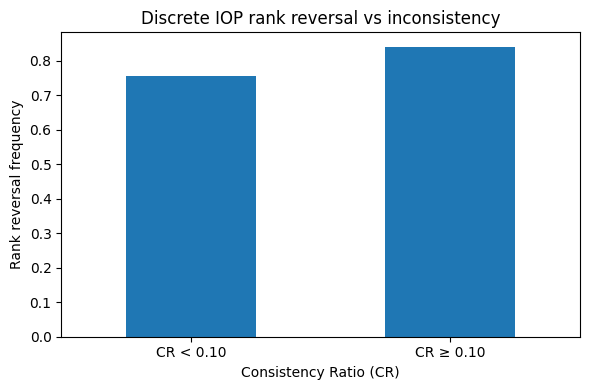


Figure saved to: discrete\discrete_iop_rank_reversal_vs_inconsistency.jpeg


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig

# =========================================================
# 1. Eigenvector priority method
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance (avoid spurious reversals)
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    """
    Ranking comparison with tolerance:
    two weights are treated as equal if they differ by less than tol.
    Returns rank positions (1 = best).
    """
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):
    """
    Generate random ordinal reciprocal matrix with entries:
    {1, P, 1/P}
    """

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:  # notpref
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A

# =========================================================
# 4. Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):

    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A

# =========================================================
# 5. Consistency Ratio (Saaty)
# =========================================================

def consistency_ratio(A):

    n = A.shape[0]

    RI_table = {
        1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
        6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49
    }

    eigenvalues, _ = eig(A)
    lambda_max = np.max(eigenvalues.real)

    CI = (lambda_max - n) / (n - 1)

    RI = RI_table.get(n, None)
    if RI is None:
        raise ValueError("RI not available for n > 10")

    if RI == 0:
        return 0.0

    return CI / RI

# =========================================================
# 6. Discrete simulation with CR (2-group standard)
# =========================================================

def simulate_discrete_reversals_with_cr(n, trials=10000, tol=1e-10):

    records = []
    alpha_values = list(range(2, 10))  # alpha = 2,...,9

    for _ in range(trials):

        # Step 1: ordinal structure
        A_ord = random_ordinal_pcm(n)

        # Step 2: baseline alpha = 2
        A_base = substitute_alpha(A_ord, 2)

        cr = consistency_ratio(A_base)

        w_base = eigenvector_priority(A_base)
        rank_base = ranking_with_ties(w_base, tol)

        reversal = 0

        # Step 3: intensify alpha = 3,...,9
        for alpha in alpha_values[1:]:

            A_new = substitute_alpha(A_ord, alpha)
            w_new = eigenvector_priority(A_new)
            rank_new = ranking_with_ties(w_new, tol)

            if not np.array_equal(rank_base, rank_new):
                reversal = 1
                break

        records.append((cr, reversal))

    return pd.DataFrame(records, columns=["CR", "Reversal"])

# =========================================================
# 7. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 8. Run experiment
# =========================================================

np.random.seed(42)

n = 7
trials = 10000

print(f"Running DISCRETE CR analysis for n={n}...\n")

df = simulate_discrete_reversals_with_cr(n=n, trials=trials)

# Save raw results
excel_path = os.path.join(output_dir, "discrete_cr_analysis.xlsx")
df.to_excel(excel_path, index=False)

print(f"Raw results saved to: {excel_path}")

# =========================================================
# 9. Group by STANDARD AHP threshold (CR = 0.10)
# =========================================================

bins = [0.0, 0.10, np.inf]
labels = ["CR < 0.10", "CR ≥ 0.10"]

df["CR_group"] = pd.cut(df["CR"], bins=bins, labels=labels)

# Rank reversal frequency by group
summary = df.groupby("CR_group", observed=False)["Reversal"].mean()

# Group sizes
counts = df["CR_group"].value_counts()

print("\nNumber of matrices per CR group:\n")
print(counts)

print("\nRank reversal frequency by CR group:\n")
print(summary)

# Save summary table
summary_df = summary.reset_index()
summary_df.to_excel(
    os.path.join(output_dir, "discrete_cr_summary.xlsx"),
    index=False
)

# =========================================================
# 10. Plot results (journal style)
# =========================================================

ax = summary.plot(kind="bar", figsize=(6, 4))

ax.set_xlabel("Consistency Ratio (CR)")
ax.set_ylabel("Rank reversal frequency")
ax.set_title("Discrete IOP rank reversal vs inconsistency")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    "discrete_iop_rank_reversal_vs_inconsistency.jpeg"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigure saved to: {figure_path}")



In [7]:
print(df["CR_group"].value_counts())

CR_group
CR < 0.10           6375
0.10 ≤ CR < 0.15    3602
CR ≥ 0.15             23
Name: count, dtype: int64


Running DISCRETE comparison across 7 methods...

Eigenvector          | n=4 -> 0.0450
Eigenvector          | n=5 -> 0.3763
Eigenvector          | n=6 -> 0.6167
Eigenvector          | n=7 -> 0.7883
Eigenvector          | n=8 -> 0.8943
Geometric mean       | n=4 -> 0.0000
Geometric mean       | n=5 -> 0.0000
Geometric mean       | n=6 -> 0.0000
Geometric mean       | n=7 -> 0.0000
Geometric mean       | n=8 -> 0.0000
Row sum              | n=4 -> 0.0000
Row sum              | n=5 -> 0.0603
Row sum              | n=6 -> 0.1660
Row sum              | n=7 -> 0.3033
Row sum              | n=8 -> 0.4607
Column sum           | n=4 -> 0.1550
Column sum           | n=5 -> 0.4070
Column sum           | n=6 -> 0.6340
Column sum           | n=7 -> 0.8147
Column sum           | n=8 -> 0.9157
Harmonic mean        | n=4 -> 0.0000
Harmonic mean        | n=5 -> 0.0517
Harmonic mean        | n=6 -> 0.1540
Harmonic mean        | n=7 -> 0.2973
Harmonic mean        | n=8 -> 0.4337
Cosine max           | n=4

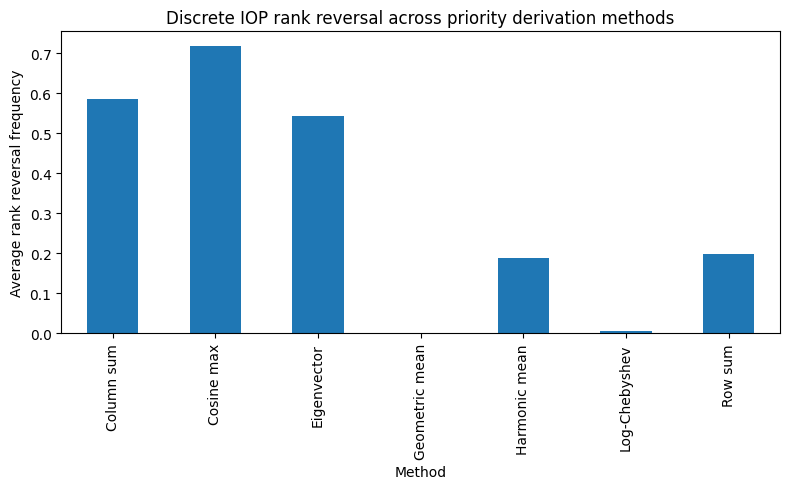


Results saved to: discrete\discrete_comparison_7_methods.xlsx
Figure saved to: discrete\discrete_comparison_7_methods.jpeg

LaTeX table:

\begin{table}
\caption{Average discrete IOP rank reversal frequency across seven priority derivation methods.}
\label{tab:discrete_comparison_7_methods}
\begin{tabular}{lr}
\toprule
 & Frequency \\
Method &  \\
\midrule
Column sum & 0.585300 \\
Cosine max & 0.718600 \\
Eigenvector & 0.544100 \\
Geometric mean & 0.000000 \\
Harmonic mean & 0.187300 \\
Log-Chebyshev & 0.005500 \\
Row sum & 0.198100 \\
\bottomrule
\end{tabular}
\end{table}



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from numpy.linalg import eig
from scipy.optimize import linprog

# =========================================================
# 1. Priority derivation methods
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)


def geometric_mean_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    return gm / np.sum(gm)


def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return rs / np.sum(rs)


# ✅ Correct Column Sum Method (CSM)
def column_sum_priority(A):
    """
    Column Sum Method:
    Sum of column-normalised entries.
    """

    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.sum(norm_matrix, axis=1)

    return w / np.sum(w)


def harmonic_mean_priority(A):
    n = A.shape[0]
    hm = n / np.sum(1 / A, axis=1)
    return hm / np.sum(hm)


def cosine_maximization_priority(A):
    n = A.shape[0]
    b = np.zeros_like(A)

    for j in range(n):
        denom = np.sum(A[:, j] ** 2)
        for i in range(n):
            b[i, j] = A[i, j] / denom

    s = np.sum(b, axis=1)
    return s / np.sum(s)


def log_chebyshev_priority(A):
    """
    Log-Chebyshev (Minimax) method via linear programming
    """

    n = A.shape[0]
    logA = np.log(A)

    num_vars = n + 1
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:

                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    c = np.zeros(num_vars)
    c[-1] = 1

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                  bounds=bounds, method="highs")

    if not res.success:
        raise RuntimeError("Log-Chebyshev LP did not converge")

    x = res.x[:n]
    w = np.exp(x)

    return w / np.sum(w)

# =========================================================
# 2. Ranking with tolerance
# =========================================================

def ranking_with_ties(weights, tol=1e-10):
    n = len(weights)
    ranks = np.zeros(n, dtype=int)

    for i in range(n):
        rank = 1
        for j in range(n):
            if weights[j] > weights[i] + tol:
                rank += 1
        ranks[i] = rank

    return ranks

# =========================================================
# 3. Generate ORDINAL PCM
# =========================================================

def random_ordinal_pcm(n):

    A = np.ones((n, n), dtype=object)

    for i in range(n):
        for j in range(i + 1, n):

            choice = np.random.choice(["tie", "pref", "notpref"])

            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1

            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"

            else:
                A[i, j] = "1/P"
                A[j, i] = "P"

    return A

# =========================================================
# 4. Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):

    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)

    for i in range(n):
        for j in range(n):

            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0

    return A

# =========================================================
# 5. Discrete rank reversal frequency
# =========================================================

def discrete_rank_reversal_frequency(method, n,
                                     trials=3000, tol=1e-10):

    reversals = 0
    alpha_values = list(range(2, 10))

    for _ in range(trials):

        A_ord = random_ordinal_pcm(n)

        A_base = substitute_alpha(A_ord, 2)
        w_base = method(A_base)
        r_base = ranking_with_ties(w_base, tol)

        reversal = False

        for alpha in alpha_values[1:]:

            A_new = substitute_alpha(A_ord, alpha)
            w_new = method(A_new)
            r_new = ranking_with_ties(w_new, tol)

            if not np.array_equal(r_base, r_new):
                reversal = True
                break

        if reversal:
            reversals += 1

    return reversals / trials

# =========================================================
# 6. Create output folder
# =========================================================

output_dir = "discrete"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 7. Run Monte Carlo comparison
# =========================================================

np.random.seed(42)

methods = {
    "Eigenvector": eigenvector_priority,
    "Geometric mean": geometric_mean_priority,
    "Row sum": row_sum_priority,
    "Column sum": column_sum_priority,
    "Harmonic mean": harmonic_mean_priority,
    "Cosine max": cosine_maximization_priority,
    "Log-Chebyshev": log_chebyshev_priority
}

n_values = [4, 5, 6, 7, 8]
trials = 3000
tol = 1e-10

records = []

print("Running DISCRETE comparison across 7 methods...\n")

for name, method in methods.items():
    for n in n_values:

        freq = discrete_rank_reversal_frequency(
            method=method,
            n=n,
            trials=trials,
            tol=tol
        )

        records.append((name, n, freq))
        print(f"{name:20s} | n={n} -> {freq:.4f}")

# =========================================================
# 8. Results table
# =========================================================

df = pd.DataFrame(records,
                  columns=["Method", "n", "Frequency"])

summary = df.groupby("Method")["Frequency"].mean().round(4)

print("\nAverage DISCRETE IOP rank reversal frequency:\n")
print(summary)

excel_path = os.path.join(
    output_dir,
    "discrete_comparison_7_methods.xlsx"
)

df.to_excel(excel_path, index=False)

# =========================================================
# 9. Bar plot
# =========================================================

ax = summary.plot(kind="bar", figsize=(8, 5))

ax.set_ylabel("Average rank reversal frequency")
ax.set_title("Discrete IOP rank reversal across priority derivation methods")

plt.tight_layout()

figure_path = os.path.join(
    output_dir,
    "discrete_comparison_7_methods.jpeg"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nResults saved to: {excel_path}")
print(f"Figure saved to: {figure_path}")

# =========================================================
# 10. LaTeX table
# =========================================================

latex_table = summary.to_frame().to_latex(
    caption="Average discrete IOP rank reversal frequency across seven priority derivation methods.",
    label="tab:discrete_comparison_7_methods"
)

print("\nLaTeX table:\n")
print(latex_table)

In [7]:
#ejemplos

In [9]:
import numpy as np
from numpy.linalg import eig

# =========================================================
# Priority derivation methods
# =========================================================

def eigenvector_priority(A):
    eigenvalues, eigenvectors = eig(A)
    idx = np.argmax(eigenvalues.real)
    w = np.abs(eigenvectors[:, idx].real)
    return w / np.sum(w)

def geometric_mean_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    return gm / np.sum(gm)

def arithmetic_mean_priority(A):
    am = np.mean(A, axis=1)
    return am / np.sum(am)

def column_sum_priority(A):
    col_sums = np.sum(A, axis=0)
    norm_matrix = A / col_sums
    w = np.mean(norm_matrix, axis=1)
    return w / np.sum(w)

def sscsm_priority(A):
    col_sums = np.sum(A, axis=0)
    w = np.sum(A / col_sums, axis=1)
    return w / np.sum(w)

def cosine_maximization_priority(A):
    n = A.shape[0]
    b = np.zeros_like(A)
    for j in range(n):
        denom = np.sum(A[:, j] ** 2)
        for i in range(n):
            b[i, j] = A[i, j] / denom
    s = np.sum(b, axis=1)
    return s / np.sum(s)

def express_ahp_priority(A):
    gm = np.prod(A, axis=1) ** (1 / A.shape[0])
    best = np.argmax(gm)
    w = A[:, best]
    return w / np.sum(w)

# =========================================================
# Ranking
# =========================================================

def ranking(weights):
    return np.argsort(-weights)

# =========================================================
# Ordinal PCM generator
# =========================================================

def random_ordinal_pcm(n):
    A = np.ones((n, n), dtype=object)
    for i in range(n):
        for j in range(i + 1, n):
            choice = np.random.choice(["tie", "pref", "notpref"])
            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1
            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"
            else:
                A[i, j] = "1/P"
                A[j, i] = "P"
    return A

# =========================================================
# Substitute alpha
# =========================================================

def substitute_alpha(A_ord, alpha):
    n = A_ord.shape[0]
    A = np.ones((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0
    return A

# =========================================================
# Pretty printing
# =========================================================

def print_matrix(A):
    for row in A:
        print("   ".join(f"{x:6.3f}" for x in row))

def print_weights(w):
    print(", ".join(f"{x:.4f}" for x in w))

# =========================================================
# Find and display explicit rank reversal
# =========================================================

def find_and_print_example(method, method_name, n=5, max_tries=50000):

    alpha_values = list(range(2, 10))

    for attempt in range(max_tries):

        A_ord = random_ordinal_pcm(n)

        A2 = substitute_alpha(A_ord, 2)
        w2 = method(A2)
        r2 = ranking(w2)

        for alpha in alpha_values[1:]:

            Aalpha = substitute_alpha(A_ord, alpha)
            wa = method(Aalpha)
            ra = ranking(wa)

            if not np.array_equal(r2, ra):

                print("="*60)
                print(f"METHOD: {method_name}")
                print(f"Matrix size n = {n}")
                print("-"*60)

                print("\nBaseline α = 2")
                print("Matrix A(2):")
                print_matrix(A2)

                print("\nPriority vector:")
                print_weights(w2)

                print("Ranking:", r2)

                print("\nIntensified α =", alpha)
                print("Matrix A(alpha):")
                print_matrix(Aalpha)

                print("\nPriority vector:")
                print_weights(wa)

                print("Ranking:", ra)

                print("\n>>> IOP RANK REVERSAL DETECTED <<<")
                print("="*60 + "\n")

                return

    print(f"No example found for {method_name}\n")

# =========================================================
# MAIN
# =========================================================

np.random.seed(42)

methods = {
    "Eigenvector": eigenvector_priority,
    "Arithmetic mean": arithmetic_mean_priority,
    "Column sum": column_sum_priority,
    "SSCSM": sscsm_priority,
    "Cosine max": cosine_maximization_priority,
    "Express AHP": express_ahp_priority
}

print("\nSearching explicit rank reversal examples...\n")

for name, method in methods.items():
    find_and_print_example(method, name, n=5)

# =========================================================
# Check geometric mean invariance
# =========================================================

print("\nChecking invariance of geometric mean method...\n")

A_ord = random_ordinal_pcm(5)
A2 = substitute_alpha(A_ord, 2)
A9 = substitute_alpha(A_ord, 9)

w2 = geometric_mean_priority(A2)
w9 = geometric_mean_priority(A9)

print("Ranking at α=2:", ranking(w2))
print("Ranking at α=9:", ranking(w9))
print("\nGeometric mean ranking is invariant.\n")



Searching explicit rank reversal examples...

METHOD: Eigenvector
Matrix size n = 5
------------------------------------------------------------

Baseline α = 2
Matrix A(2):
 1.000    1.000    1.000    2.000    2.000
 1.000    1.000    1.000    1.000    1.000
 1.000    1.000    1.000    0.500    0.500
 0.500    1.000    2.000    1.000    0.500
 0.500    1.000    2.000    2.000    1.000

Priority vector:
0.2636, 0.1888, 0.1514, 0.1713, 0.2249
Ranking: [0 4 1 3 2]

Intensified α = 9
Matrix A(alpha):
 1.000    1.000    1.000    9.000    9.000
 1.000    1.000    1.000    1.000    1.000
 1.000    1.000    1.000    0.111    0.111
 0.111    1.000    9.000    1.000    0.111
 0.111    1.000    9.000    9.000    1.000

Priority vector:
0.4461, 0.1146, 0.0778, 0.1154, 0.2462
Ranking: [0 4 3 1 2]

>>> IOP RANK REVERSAL DETECTED <<<

METHOD: Arithmetic mean
Matrix size n = 5
------------------------------------------------------------

Baseline α = 2
Matrix A(2):
 1.000    2.000    0.500    2.000 

In [14]:
import numpy as np
from numpy.linalg import eig
from scipy.optimize import linprog

# =========================================================
# Priority methods (solo los que faltan)
# =========================================================

def row_sum_priority(A):
    rs = np.sum(A, axis=1)
    return rs / np.sum(rs)

def harmonic_mean_priority(A):
    hm = 1 / np.sum(1 / A, axis=1)
    return hm / np.sum(hm)

def log_chebyshev_priority(A):
    n = A.shape[0]
    logA = np.log(A)

    num_vars = n + 1
    bounds = [(None, None)] * n + [(0, None)]

    A_ub = []
    b_ub = []

    for i in range(n):
        for j in range(n):
            if i != j:
                row1 = np.zeros(num_vars)
                row1[i] = -1
                row1[j] = 1
                row1[-1] = -1
                A_ub.append(row1)
                b_ub.append(-logA[i, j])

                row2 = np.zeros(num_vars)
                row2[i] = 1
                row2[j] = -1
                row2[-1] = -1
                A_ub.append(row2)
                b_ub.append(logA[i, j])

    c = np.zeros(num_vars)
    c[-1] = 1

    res = linprog(c, A_ub=np.array(A_ub),
                  b_ub=np.array(b_ub),
                  bounds=bounds,
                  method="highs")

    x = res.x[:n]
    w = np.exp(x)
    return w / np.sum(w)

# =========================================================
# Ranking
# =========================================================

def ranking(w):
    return np.argsort(-w)

# =========================================================
# Ordinal PCM generator
# =========================================================

def random_ordinal_pcm(n):
    A = np.ones((n, n), dtype=object)
    for i in range(n):
        for j in range(i + 1, n):
            choice = np.random.choice(["tie", "pref", "notpref"])
            if choice == "tie":
                A[i, j] = 1
                A[j, i] = 1
            elif choice == "pref":
                A[i, j] = "P"
                A[j, i] = "1/P"
            else:
                A[i, j] = "1/P"
                A[j, i] = "P"
    return A

def substitute_alpha(A_ord, alpha):
    n = A_ord.shape[0]
    A = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if A_ord[i, j] == "P":
                A[i, j] = alpha
            elif A_ord[i, j] == "1/P":
                A[i, j] = 1 / alpha
            else:
                A[i, j] = 1.0
    return A

# =========================================================
# Pretty print
# =========================================================

def print_matrix(A):
    for row in A:
        print("  ".join(f"{x:6.3f}" for x in row))

def print_weights(w):
    print(", ".join(f"{x:.4f}" for x in w))

# =========================================================
# Find explicit example
# =========================================================

def find_example(method, name, n=5, max_tries=80000):

    for _ in range(max_tries):

        A_ord = random_ordinal_pcm(n)
        A2 = substitute_alpha(A_ord, 2)

        w2 = method(A2)
        r2 = ranking(w2)

        for alpha in range(3, 10):

            Aalpha = substitute_alpha(A_ord, alpha)
            wa = method(Aalpha)
            ra = ranking(wa)

            if not np.array_equal(r2, ra):

                print("="*60)
                print(f"METHOD: {name}")
                print(f"n = {n}")
                print("-"*60)

                print("\nA(2):")
                print_matrix(A2)
                print("\nRanking α=2:", r2)

                print("\nA(alpha), alpha =", alpha)
                print_matrix(Aalpha)
                print("\nRanking α=", alpha, ":", ra)

                print("\n>>> IOP RANK REVERSAL DETECTED <<<")
                print("="*60 + "\n")

                return

    print(f"No example found for {name}")

# =========================================================
# MAIN
# =========================================================

np.random.seed(123)

methods = {
    "Row sum": row_sum_priority,
    "Harmonic mean": harmonic_mean_priority,
    "Log-Chebyshev": log_chebyshev_priority
}

print("\nSearching explicit examples...\n")

for name, method in methods.items():
    find_example(method, name, n=5)



Searching explicit examples...

METHOD: Row sum
n = 5
------------------------------------------------------------

A(2):
 1.000   0.500   2.000   0.500   0.500
 2.000   1.000   1.000   0.500   0.500
 0.500   1.000   1.000   2.000   0.500
 2.000   2.000   0.500   1.000   2.000
 2.000   2.000   2.000   0.500   1.000

Ranking α=2: [3 4 1 2 0]

A(alpha), alpha = 3
 1.000   0.333   3.000   0.333   0.333
 3.000   1.000   1.000   0.333   0.333
 0.333   1.000   1.000   3.000   0.333
 3.000   3.000   0.333   1.000   3.000
 3.000   3.000   3.000   0.333   1.000

Ranking α= 3 : [4 3 1 2 0]

>>> IOP RANK REVERSAL DETECTED <<<

METHOD: Harmonic mean
n = 5
------------------------------------------------------------

A(2):
 1.000   0.500   2.000   1.000   1.000
 2.000   1.000   1.000   1.000   2.000
 0.500   1.000   1.000   0.500   1.000
 1.000   1.000   2.000   1.000   0.500
 1.000   0.500   1.000   2.000   1.000

Ranking α=2: [1 0 3 4 2]

A(alpha), alpha = 3
 1.000   0.333   3.000   1.000   1.00